In [1]:
from pathlib import Path

BASE_DIR = Path(r"C:\Users\bhall\OneDrive\Desktop\project\data")

color_dir = BASE_DIR / "color"
grayscale_dir = BASE_DIR / "grayscale"
segmented_dir = BASE_DIR / "segmented"

print("Color exists:", color_dir.exists())
print("Grayscale exists:", grayscale_dir.exists())
print("Segmented exists:", segmented_dir.exists())

Color exists: True
Grayscale exists: True
Segmented exists: True


In [2]:
# Count the total number of disease classes in each dataset version.
# Each folder inside the dataset represents one disease/healthy class.

# We will check all three dataset versions
for dataset_name in ["color", "grayscale", "segmented"]:

    # Create the path for the current dataset
    dataset_path = BASE_DIR / dataset_name

    # Get all folder names (each folder represents one class)
    classes = [
        folder.name
        for folder in dataset_path.iterdir()
        if folder.is_dir()
    ]

    # Print total number of classes
    print(f"{dataset_name}: {len(classes)} classes")

color: 38 classes
grayscale: 38 classes
segmented: 38 classes


In [3]:
# Count total images available in each dataset version.
# This helps us understand the size of the dataset before training.


# Count total images present in each dataset

for dataset_name in ["color", "grayscale", "segmented"]:

    # Path of current dataset
    dataset_path = BASE_DIR / dataset_name

    total_images = 0

    # Visit every class folder
    for folder in dataset_path.iterdir():

        if folder.is_dir():

            # Count JPG images inside the folder
            images = list(folder.glob("*.JPG"))

            total_images += len(images)

    print(f"{dataset_name}: {total_images} images")

color: 54295 images
grayscale: 54303 images
segmented: 54306 images


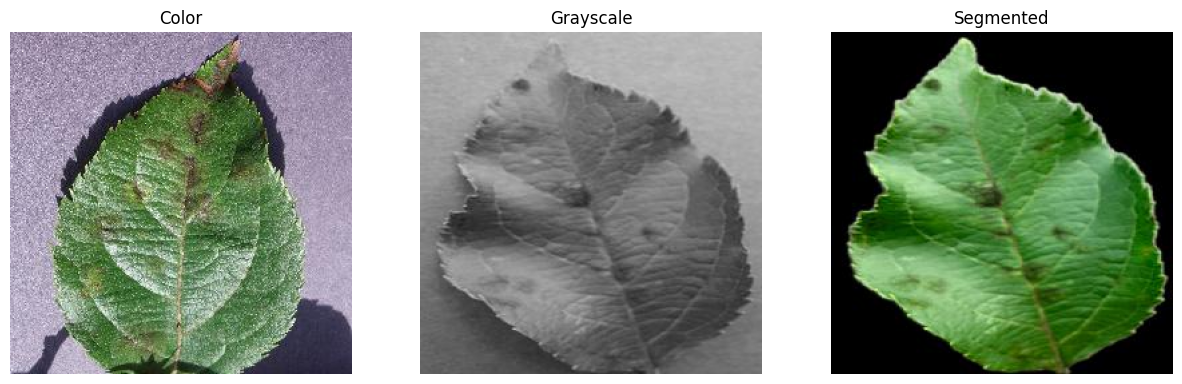

In [4]:
# Import libraries for displaying images

from PIL import Image
import matplotlib.pyplot as plt

# Select one class folder from each dataset
color_sample = next((color_dir / "Apple___Apple_scab").glob("*.JPG"))
gray_sample = next((grayscale_dir / "Apple___Apple_scab").glob("*.JPG"))
segment_sample = next((segmented_dir / "Apple___Apple_scab").glob("*.JPG"))

# Open images
color_img = Image.open(color_sample)
gray_img = Image.open(gray_sample)
segment_img = Image.open(segment_sample)

# Display images
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(color_img)
plt.title("Color")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray_img, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(segment_img)
plt.title("Segmented")
plt.axis("off")

plt.show()

In [5]:
# Count number of images in each class for color, grayscale, and segmented datasets
# This helps us check whether the dataset is balanced or imbalanced.

for dataset_name in ["color", "grayscale", "segmented"]:

    dataset_path = BASE_DIR / dataset_name

    print(f"\n--- {dataset_name.upper()} DATASET ---")

    for folder in sorted(dataset_path.iterdir()):

        if folder.is_dir():

            images = list(folder.glob("*.JPG"))

            print(f"{folder.name}: {len(images)}")


--- COLOR DATASET ---
Apple___Apple_scab: 622
Apple___Black_rot: 621
Apple___Cedar_apple_rust: 275
Apple___healthy: 1645
Blueberry___healthy: 1502
Cherry_(including_sour)___healthy: 854
Cherry_(including_sour)___Powdery_mildew: 1052
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513
Corn_(maize)___Common_rust_: 1192
Corn_(maize)___healthy: 1162
Corn_(maize)___Northern_Leaf_Blight: 985
Grape___Black_rot: 1180
Grape___Esca_(Black_Measles): 1383
Grape___healthy: 423
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076
Orange___Haunglongbing_(Citrus_greening): 5507
Peach___Bacterial_spot: 2297
Peach___healthy: 360
Pepper,_bell___Bacterial_spot: 997
Pepper,_bell___healthy: 1477
Potato___Early_blight: 1000
Potato___healthy: 152
Potato___Late_blight: 1000
Raspberry___healthy: 371
Soybean___healthy: 5090
Squash___Powdery_mildew: 1835
Strawberry___healthy: 456
Strawberry___Leaf_scorch: 1109
Tomato___Bacterial_spot: 2127
Tomato___Early_blight: 1000
Tomato___healthy: 1591
Tomato___Late_blight: 